In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/colab đại học/môn python/financial_companies.csv')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:
standard_columns = df.columns.str.strip().str.lower()
new_columns = dict(zip(df.columns, standard_columns))
df.rename(columns=new_columns, inplace=True)

Dự án: Phân tích các chỉ số tài chính của doanh nghiệp kèm kiểm định giả thuyết thống kê

Thực hiện phân tích các chỉ số tài chính của 100 doanh nghiệp trong năm vừa qua.Mục tiêu của dự án: Nghiên cứu mối quan hệ giữa các chỉ số tài chính của doanh nghiệp và kiểm định một số giả thuyết kinh tế bằng cách sử dụng các kiểm định thống kê.

Mô tả dữ liệu:

Ownership_Type — Loại hình sở hữu (biến phân loại): Private — tư nhân; Public — đại chúng (niêm yết).

Revenue_Mln — Doanh thu năm vừa qua, triệu RUB.

EBITDA_Mln — EBITDA năm vừa qua, triệu RUB (Lợi nhuận trước lãi vay, thuế và khấu hao).

Debt_Ratio — Hệ số đòn bẩy nợ (tỷ lệ nợ trên vốn chủ sở hữu).

ROE_Percent — Tỷ suất sinh lời trên vốn chủ sở hữu, %.

Debt_Ratio_Prev — Hệ số đòn bẩy nợ của năm trước đó.

I. Làm quen dữ liệu

Hiển thị 5 dòng đầu tiên của bộ dữ liệu.

Xác định kích thước của bộ dữ liệu (số dòng và số cột).

Lấy danh sách tất cả các tên cột.

Kiểm tra kiểu dữ liệu của từng biến.

Đánh giá sự tồn tại của giá trị khuyết (NaN) trong mỗi cột.

Nghiên cứu các thống kê mô tả cơ bản cho các biến số: Giá trị trung bình; Trung vị; Độ lệch chuẩn; Giá trị nhỏ nhất và lớn nhất; Các tứ phân vị (25%, 75%).

Phân tích phân phối của biến phân loại Ownership_Type:

Số lượng quan sát theo từng loại hình;

Tỷ lệ phần trăm của các loại hình.

Viết nhận xét (kết luận).

In [4]:
# Hiển thị 5 dòng đầu tiên của bộ dữ liệu.
print(df.head(5))
# Xác định kích thước của bộ dữ liệu (số dòng và số cột).
print(df.shape)
# Lấy danh sách tất cả các tên cột.
print(df.columns)
# Kiểm tra kiểu dữ liệu của từng biến.
print(df.info())
# Đánh giá sự tồn tại của giá trị khuyết (NaN) trong mỗi cột.
print(df.isnull().sum())
# Nghiên cứu các thống kê mô tả cơ bản cho các biến số: Giá trị trung bình; Trung vị; Độ lệch chuẩn; Giá trị nhỏ nhất và lớn nhất; Các tứ phân vị (25%, 75%).
df.describe()
# Phân tích phân phối của biến phân loại Ownership_Type:
private = df[(df['ownership_type']=='Private')] # private là 1 series
public = df[(df['ownership_type']=='Public')]
# Số lượng quan sát theo từng loại hình;
print('số lượng private',len(private))
print('số lượng public',len(public))
# Tỷ lệ phần trăm của các loại hình.
print('tỷ lệ private',len(private)/len(df))
print('tỷ lệ public',len(public)/len(df))
# Nhận xét
# công ty tư nhân chiếm số lượng lớn hơn, gần như là gấp đôi số lượng công ty đại chúng

  ownership_type  revenue_mln  ebitda_mln  debt_ratio  roe_percent  \
0        Private   513.057060  128.589312    1.599530     4.820723   
1         Public   455.148897  150.125576    1.199892     5.950894   
2         Public   513.764116  121.824608    1.534901     9.290200   
3        Private   201.864663  118.470395    1.307343     2.116360   
4        Private   467.049217  132.403988    1.556759     0.026765   

   debt_ratio_prev  
0         1.776750  
1         1.027347  
2         1.521350  
3         1.246869  
4         1.914181  
(100, 6)
Index(['ownership_type', 'revenue_mln', 'ebitda_mln', 'debt_ratio',
       'roe_percent', 'debt_ratio_prev'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ownership_type   100 non-null    object 
 1   revenue_mln      100 non-null    float64
 2   ebitda_mln       100

II. Phân tích mối quan hệ và phân phối dữ liệu

1. Xây dựng ma trận tương quan bằng corr() rồi trực quan hóa bằng biểu đồ nhiệt heatmap(): sử dụng bảng màu coolwarm; hiển thị giá trị hệ số với độ chính xác 2 chữ số thập phân; thêm tiêu đề: "Ma trận tương quan các chỉ số tài chính".

2. Đánh giá mức độ và hướng của các mối quan hệ: Tương quan dương mạnh (r > 0,7) giữa Revenue_Mln và EBITDA_Mln cho thấy rằng tăng trưởng doanh thu dẫn đến tăng lợi nhuận hoạt động; Tương quan âm giữa Debt_Ratio và ROE_Percent có thể chỉ ra rằng gánh nặng nợ cao làm giảm tỷ suất sinh lời trên vốn chủ sở hữu;Tương quan yếu (|r| < 0,3) nghĩa là không có mối quan hệ tuyến tính có ý nghĩa giữa các chỉ số.

3. Viết kết luận.

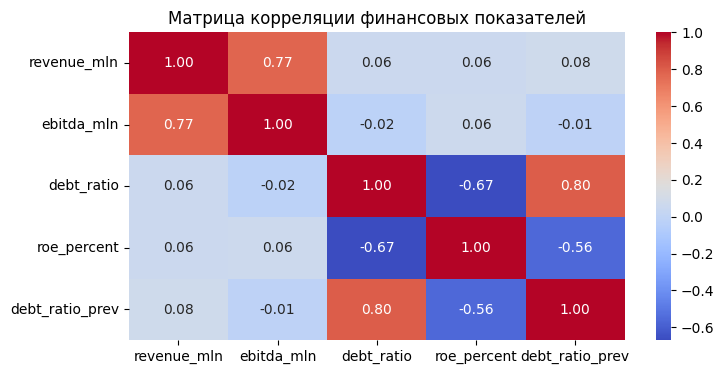

In [5]:
cor = df.corr(numeric_only=True)
plt.figure(figsize=(8,4))
sns.heatmap(cor,cmap= 'coolwarm',fmt='.2f',annot = True) # annot là annotation tức chú thích dùng để hiển thị số
plt. title ('Матрица корреляции финансовых показателей')
plt.show()

# r(revenue và ebitda) = 0.77 thể hiện sự tương quan mạnh cho thấy tăng trưởng doanh thu dẫn đến tăng lợi nhuận hoạt động, revenue, ebitda và các biến còn lại ko có tương quan
# r(roe và debt) = -0.67 thể hiện gánh nặng nợ cao làm giảm tỷ suất sinh lời trên vốn chủ sở hữu

III. Pairplot: dùng để trực quan hóa mối quan hệ giữa nhiều cặp biến số cùng một lúc.

1. Phân tích mối quan hệ giữa doanh thu, EBITDA, hệ số đòn bẩy nợ và ROE. Lưu ý: sự tồn tại của các mối quan hệ tuyến tính (ví dụ: tăng trưởng doanh thu → tăng EBITDA); sự khác biệt trong các mẫu hình giữa doanh nghiệp tư nhân và doanh nghiệp đại chúng; các điểm ngoại lai (outlier) có thể làm sai lệch bức tranh tổng thể.

2. Xây dựng pairplot với mã hóa màu sắc theo loại hình sở hữu (Ownership_Type) (sử dụng tham số hue): sử dụng bảng màu Set2; độ trong suốt của điểm: alpha = 0.7;kích thước điểm: s = 60;

3. tiêu đề: "Ma trận phân phối các chỉ số tài chính của doanh nghiệp (mã hóa màu theo loại hình sở hữu)" (sử dụng plt.suptitle())

Viết nhận xét (kết luận).

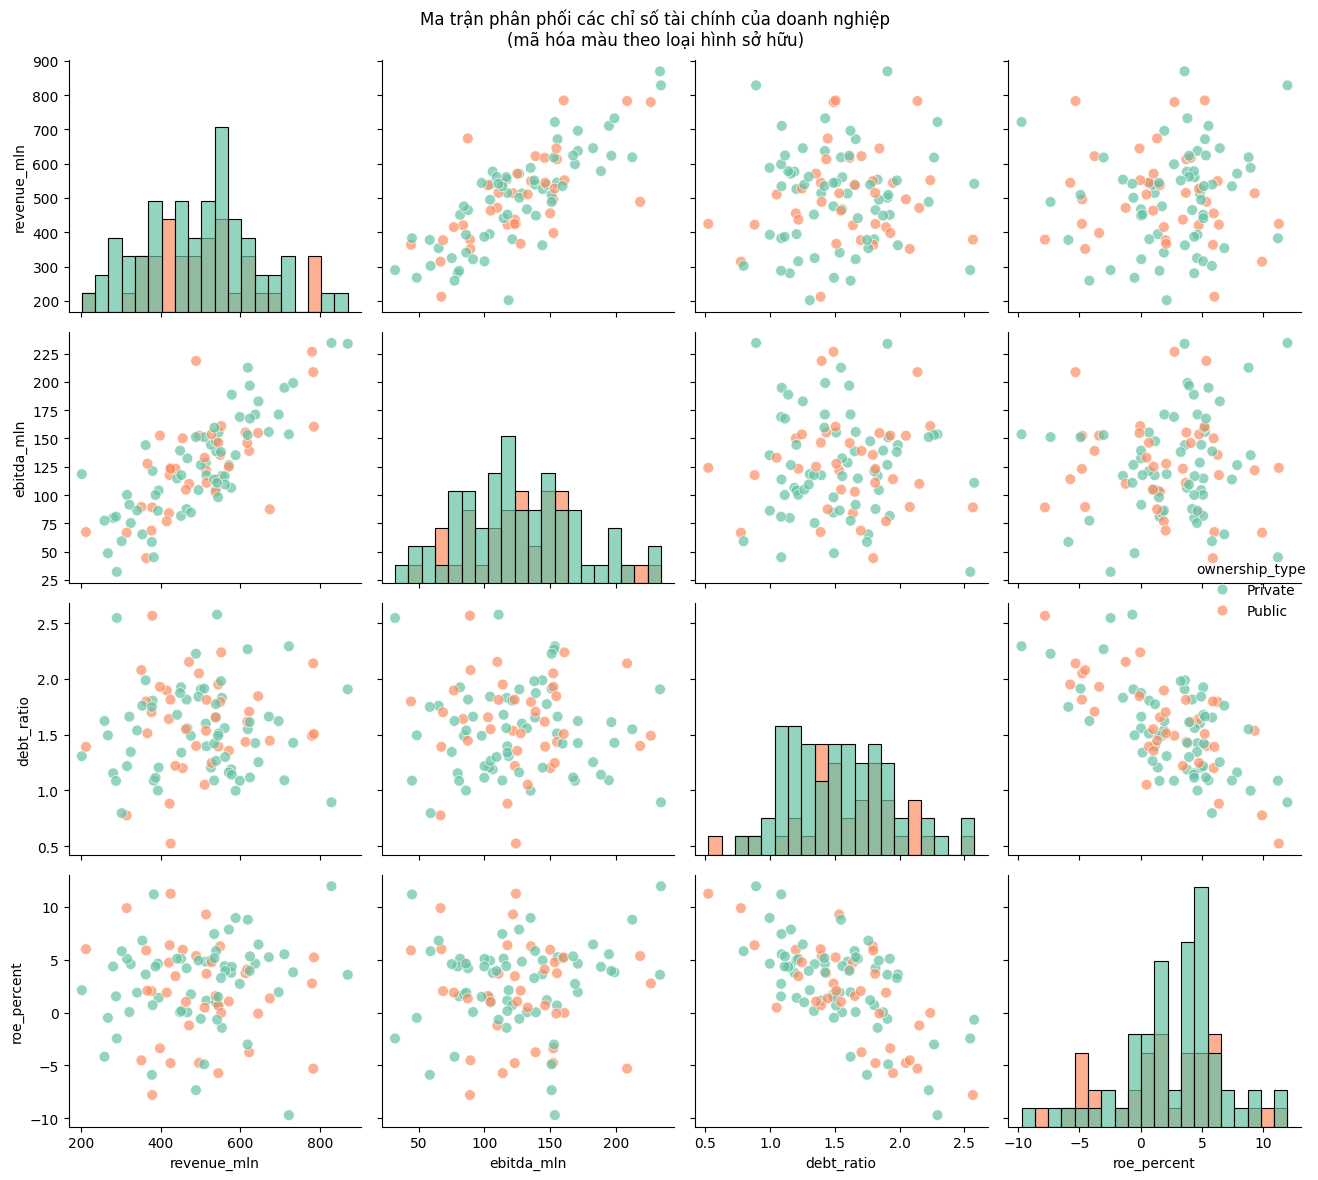

In [6]:
data_pair= df[['revenue_mln', 'ebitda_mln', 'debt_ratio', 'roe_percent', 'ownership_type']]
pairplot = sns.pairplot(
    data=data_pair,
    hue='ownership_type',           # Phân loại màu theo loại hình sở hữu
    palette='Set2',                 # Bảng màu Set2
    kind='scatter',                 # Loại đồ thị: scatter (mặc định)
    diag_kind='hist',               # Biểu đồ histogram trên đường chéo
    plot_kws={'alpha': 0.7, 's': 60},     # Độ trong suốt và kích thước điểm
    diag_kws={'bins': 20, 'alpha': 0.7},  # Tham số cho histogram
    height=3,                       # Kích thước mỗi ô
)

# Thêm tiêu đề
plt.suptitle('Ma trận phân phối các chỉ số tài chính của doanh nghiệp\n(mã hóa màu theo loại hình sở hữu)')
plt.tight_layout()
plt.show()

#kết luận

IV. Kiểm định giả thuyết thống kê

Đối với mỗi kiểm định: Tính thống kê t và giá trị p; Đưa ra kết luận với mức ý nghĩa α = 0,05; Diễn giải kết quả trong bối cảnh kinh tế.

Giả thuyết 1: Doanh thu trung bình của các công ty vượt quá 480 triệu RUB. H₀: μ ≤ 480. H₁: μ > 480. Diễn giải kinh tế: Nếu giả thuyết được xác nhận, điều này có nghĩa là các công ty trong mẫu đang hoạt động hiệu quả hơn mức trung bình của ngành. Điều này có thể liên quan đến môi trường thị trường thuận lợi hoặc do sự tập trung cao của các doanh nghiệp thành công trong mẫu nghiên cứu.

Giả thuyết 2: Tỷ suất sinh lời trên vốn chủ sở hữu (ROE) không vượt quá 15%. H₀: μ ≥ 15. H₁: μ < 15. Diễn giải kinh tế: Nếu ROE thấp hơn đáng kể so với mức 15%, điều này có thể cho thấy: hiệu quả quản lý vốn thấp; gánh nặng nợ cao, "ăn mòn" lợi nhuận; điều kiện kinh tế vĩ mô bất lợi.

Giả thuyết 3: Các công ty đại chúng (public) có EBITDA cao hơn các công ty tư nhân (private). H₀: μ₁ ≤ μ₂ (EBITDA của công ty đại chúng ≤ EBITDA của công ty tư nhân). H₁: μ₁ > μ₂ (EBITDA của công ty đại chúng > EBITDA của công ty tư nhân). Diễn giải kinh tế: EBITDA cao hơn ở các công ty đại chúng có thể được giải thích bởi: khả năng tiếp cận nguồn vốn huy động công khai với chi phí rẻ hơn; lợi thế kinh tế nhờ quy mô; quy trình quản lý hiệu quả hơn.

Giả thuyết 4: Các công ty tư nhân có hệ số đòn bẩy nợ thấp hơn các công ty đại chúng. H₀: μ₁ ≥ μ₂ (hệ số nợ của công ty tư nhân ≥ hệ số nợ của công ty đại chúng). H₁: μ₁ < μ₂ (hệ số nợ của công ty tư nhân < hệ số nợ của công ty đại chúng). Diễn giải kinh tế: Hệ số đòn bẩy nợ thấp hơn ở các công ty tư nhân có thể liên quan đến: sự thận trọng của chủ sở hữu trong việc huy động vốn vay; khả năng tiếp cận tín dụng hạn chế hơn khi không có trạng thái đại chúng; mong muốn duy trì toàn quyền kiểm soát doanh nghiệp.

In [11]:
from statsmodels.stats.proportion import proportions_ztest
import pandas as pd
from scipy import stats

alpha = 0.05

# H1: Revenue > 480
t1, p1 = stats.ttest_1samp(df['revenue_mln'], popmean=480, alternative = 'greater')
print("H1: Doanh thu > 480")
print("t =", round(t1, 4), "p =", round(p1, 4))
if p1 < 0.05: print("Bác bỏ H0, revenue >480")
else: print("Chưa đủ bằng chứng để bác bỏ H0 tức doanh thu trung bình bé hơn hoặc bằng 480")

# H1: ROE < 15
t2, p2 = stats.ttest_1samp(df['roe_percent'], popmean = 15, alternative= 'less' )
print("H1: ROE < 15")
print("t =", round(t2, 4), "p =", round(p2, 4))
if p2 < 0.05: print("Bác bỏ H0, ROE bé hơn 15%")
else: print("Chưa đủ bằng chứng để bác bỏ H0 tức ROE lớn hơn hoặc bằng 15%")

# H1: EBITDA public > private
pub = df[df['ownership_type'] == 'Public']['ebitda_mln']
pri = df[df['ownership_type'] == 'Private']['ebitda_mln']
t3, p3 = stats.ttest_ind(pub, pri, equal_var=True, alternative = 'greater') #nhóm nào đươc truyền vào trc rất qtrong vì liên quan đến alternative
print("H3: EBITDA public > private")
print("t =", round(t3, 4), "p =", round(p3,4))
if p3 < 0.05: print("Bác bỏ H0, EBITDA của công ty đại chúng lớn hơn công ty tư nhân")
else:  print("Chưa đủ bằng chứng để bác bỏ H0 tức EBITDA của công ty đại chúng bé hơn hoặc bằng công ty tư nhân")

# H1: Debt private < public (miu 1 < miu 2)
pri_d = df[df['ownership_type'] == 'Private']['debt_ratio']
pub_d = df[df['ownership_type'] == 'Public']['debt_ratio']
t4, p4 = stats.ttest_ind(pri_d,pub_d , equal_var=True, alternative= 'less')
print("H4: Debt private < public")
print("t =", round(t4, 4), "p =", round(p4,4))
if p4 < 0.05:  print("Bác bỏ H0, hệ số nợ của công ty tư nhân bé hơn công ty đại chúng")
else:  print("Chưa đủ bằng chứng để bác bỏ H0 tức hệ số nợ của công ty tư nhân lớn hơn hoặc bằng công ty đại chúng")

H1: Doanh thu > 480
t = 1.4487 p = 0.0753
Chưa đủ bằng chứng để bác bỏ H0 tức doanh thu trung bình bé hơn hoặc bằng 480
H1: ROE < 15
t = -29.4842 p = 0.0
Bác bỏ H0, ROE bé hơn 15%
H3: EBITDA public > private
t = 0.069 p = 0.4726
Chưa đủ bằng chứng để bác bỏ H0 tức EBITDA của công ty đại chúng bé hơn hoặc bằng công ty tư nhân
H4: Debt private < public
t = -0.8745 p = 0.192
Chưa đủ bằng chứng để bác bỏ H0 tức hệ số nợ của công ty tư nhân lớn hơn hoặc bằng công ty đại chúng


Giả thuyết 5: Hệ số đòn bẩy nợ của các công ty đã thay đổi đáng kể trong năm qua. H₀: μ_diff = 0 (không có sự thay đổi). H₁: μ_diff ≠ 0 (có sự thay đổi). Diễn giải kinh tế: Nếu bác bỏ H₀ và mức thay đổi trung bình là dương → các công ty đang gia tăng hệ số nợ (có thể để tài trợ cho tăng trưởng); Nếu mức thay đổi trung bình là âm → các công ty đang giảm nợ; Nếu không có sự thay đổi có ý nghĩa thống kê → cấu trúc vốn ổn định.

Giả thuyết 6: Tỷ lệ công ty có hệ số đòn bẩy nợ cao (Debt_Ratio > 2.0) là 30%. H₀: p = 0.3 (tỷ lệ = 30%). H₁: p ≠ 0.3. Diễn giải kinh tế: Kết quả kiểm định sẽ giúp đánh giá mức độ rủi ro tài chính trong mẫu các công ty:

Nếu bác bỏ H₀ và tỷ lệ thực tế cao hơn 30%: Thị trường có đặc điểm là tình trạng vay nợ cao; Các công ty chủ động sử dụng vốn vay (có thể để tăng trưởng trong bối cảnh lãi suất thấp); Rủi ro hệ thống gia tăng — nhiều công ty có thể gặp vấn đề khi lãi suất tăng.

Nếu bác bỏ H₀ và tỷ lệ thực tế thấp hơn 30%: Các công ty tuân theo chính sách tài chính thận trọng; Có thể khả năng tiếp cận tín dụng bị hạn chế (ví dụ: do ngân hàng thắt chặt yêu cầu); Rủi ro vỡ nợ giảm, nhưng tăng trưởng kinh doanh có thể chậm lại.

Nếu không có cơ sở để bác bỏ H₀ (p ≥ 0.05): Cấu trúc hệ số nợ phù hợp với mức kỳ vọng; Sự cân bằng giữa rủi ro và tăng trưởng được duy trì.

Giả thuyết 7: Phân phối tỷ suất sinh lời trên vốn chủ sở hữu (ROE) của các công ty tư nhân và công ty đại chúng là giống nhau. H₀: Phân phối ROE của công ty tư nhân và công ty đại chúng không khác nhau (các giá trị trung vị bằng nhau). H₁: Phân phối ROE khác nhau (các giá trị trung vị không bằng nhau). Phương pháp: Chia mẫu theo Ownership_Type và thực hiện kiểm định phi tham số Mann-Whitney.

Kết luận chung của dự án
Hãy mô tả ngắn gọn các bước chính của dự án và trả lời các câu hỏi: Các giả thuyết kinh tế chính có được xác nhận hay không? Những khác biệt nào giữa công ty tư nhân và công ty đại chúng đã được phát hiện?

In [16]:
# GIẢ THUYẾT 5: Debt_Ratio thay đổi so với năm trước tức paired t test (nhóm trước và sau)
df['debt_diff'] = df['debt_ratio'] - df['debt_ratio_prev']
t5,p5 = stats.ttest_rel(df['debt_ratio'],df['debt_ratio_prev'],alternative = 'two-sided') #thứ tự 2 nhóm ko quan trọng vì là two sided
print('t =',round(t5,4),'p =',round(p5,4))
if p5 < 0.05:
    print("Bác bỏ H0 tức có sự thay đổi")
    if df['debt_diff'].mean() > 0: # tiếp ta tính trung bình của cột debt_diff nếu lớn hơn 0 thì
        print("Các công ty đang gia tăng hệ số nợ → Có thể dùng nợ để tài trợ cho tăng trưởng, mở rộng")
    else:  print("Các công ty đang giảm hệ số nợ → Có thể đang trả nợ, giảm rủi ro tài chính")
else: print("Chưa đủ cơ sở bác bỏ H0 tức các công ty duy trì hệ số đòn bẩy nợ tương tự như năm trước, chưa có điều chỉnh đáng kể trong chính sách nợ")
#cách 2: dùng 1 mẫu chính là mẫu hiệu của 2 năm
df['debt_diff'] = df['debt_ratio'] - df['debt_ratio_prev']
t5, p5 = stats.ttest_1samp(df['debt_diff'], 0,alternative = "two-sided")
print("t =", round(t5, 4), "p =", round(p5, 4))

# GIẢ THUYẾT 6: H1: Tỷ lệ Debt_Ratio > 2.0 khác 30%
so_quan_sat_dat = (df['debt_ratio']> 2.0).sum()
tong_so_quan_sat = len(df)
ty_le = so_quan_sat_dat/tong_so_quan_sat
z6,p6 = proportions_ztest(so_quan_sat_dat, tong_so_quan_sat,value = 0.3) #proportions_ztest nhận số quan sát không phải các quan sát
print("z6 =", round(z6, 4), "p6 =", round(p6, 4))
if p6 < 0.05:
    print("Bác bỏ H0, tức tỷ lệ công ty có hệ số nợ lớn hơn 2 khác 30% ")
    if ty_le > 0.3:
        print(" Tỷ lệ thực tế  cao hơn 30%, các công ty vay nợ")
    else:print("Tỷ lệ thực tế  thấp hơn 30%")
else: print("Chưa đủ bằng chứng để bác bỏ H0 tức tỷ lệ công ty có hệ số nợ lớn hơn 2 có thể bằng 30%")

# GIẢ THUYẾT 7: ROE public vs private (Mann-Whitney)
roe_public = df[df['ownership_type'] == 'Public']['roe_percent']
roe_private = df[df['ownership_type'] == 'Private']['roe_percent']
u7, p7 = stats.mannwhitneyu(roe_public, roe_private, alternative='two-sided')
print("U =", round(u7, 4), "p =", round(p7, 4))
if p7 < 0.05: print("Bác bỏ H0, phân phối ROE của 2 loại công ty là khác nhau")
else: print("Chưa đủ cơ sở để bác bỏ H0, phân phối ROE của 2 loại công ty có thể giống nhau")

t = -4.1229 p = 0.0001
Bác bỏ H0 tức có sự thay đổi
Các công ty đang giảm hệ số nợ → Có thể đang trả nợ, giảm rủi ro tài chính
t = -4.1229 p = 0.0001
z6 = -6.0724 p6 = 0.0
Bác bỏ H0, tức tỷ lệ công ty có hệ số nợ lớn hơn 2 khác 30% 
Tỷ lệ thực tế  thấp hơn 30%
U = 1047.0 p = 0.3995
Chưa đủ cơ sở để bác bỏ H0, phân phối ROE của 2 loại công ty có thể giống nhau


KẾT LUẬN CHUNG DỰ ÁN

Các bước chính của dự án:

Kiểm định một mẫu: Đánh giá doanh thu trung bình và ROE trung bình của các công ty trong mẫu.

Kiểm định hai mẫu độc lập: So sánh EBITDA (H3) và hệ số đòn bẩy nợ (H4) giữa công ty đại chúng và công ty tư nhân.

Kiểm định ghép cặp: Đánh giá sự thay đổi hệ số đòn bẩy nợ qua năm.

Kiểm định tỷ lệ: Xác định tỷ lệ công ty có hệ số nợ cao trong mẫu.

Kiểm định phi tham số Mann-Whitney: So sánh phân phối ROE giữa hai nhóm công ty.

Các giả thuyết kinh tế chính có được xác nhận không?

Giả thuyết 1 (Doanh thu trung bình > 480 triệu RUB): Kết quả kiểm định cho thấy chưa đủ cơ sở để bác bỏ H₀ (p > 0,05). Điều này có nghĩa là doanh thu trung bình của các công ty trong mẫu không vượt trội có ý nghĩa thống kê so với mức 480 triệu RUB. Các công ty đang hoạt động ở mức tương đương trung bình ngành.

Giả thuyết 2 (ROE trung bình < 15%): Kết quả kiểm định bác bỏ H₀ (p < 0,05). ROE trung bình của các công ty thấp hơn có ý nghĩa thống kê so với mức 15%. Điều này phản ánh hiệu quả quản lý vốn chủ sở hữu còn hạn chế, có thể do gánh nặng nợ cao hoặc điều kiện kinh tế vĩ mô không thuận lợi.

Giả thuyết 3 (EBITDA của công ty đại chúng > công ty tư nhân): Kết quả kiểm định cho thấy chưa đủ cơ sở để bác bỏ H₀ (p > 0,05). EBITDA trung bình của hai nhóm công ty không có sự khác biệt có ý nghĩa thống kê. Lợi thế về khả năng tiếp cận vốn của công ty đại chúng chưa thể hiện rõ ràng trong chỉ tiêu EBITDA.

Giả thuyết 4 (Hệ số nợ của công ty tư nhân < công ty đại chúng): Kết quả kiểm định cho thấy chưa đủ cơ sở để bác bỏ H₀ (p > 0,05). Không có sự khác biệt có ý nghĩa thống kê về hệ số đòn bẩy nợ giữa hai nhóm công ty.

Giả thuyết 5 (Hệ số nợ thay đổi qua năm): Kết quả kiểm định cho thấy chưa đủ cơ sở để bác bỏ H₀ (p > 0,05). Hệ số đòn bẩy nợ của các công ty không có sự thay đổi đáng kể so với năm trước, cho thấy cấu trúc vốn tương đối ổn định.

Giả thuyết 6 (Tỷ lệ công ty có hệ số nợ > 2.0 là 30%): Kết quả kiểm định cho thấy chưa đủ cơ sở để bác bỏ H₀ (p > 0,05). Tỷ lệ công ty có hệ số nợ cao trong mẫu không khác biệt có ý nghĩa thống kê so với mức kỳ vọng 30%, phản ánh cấu trúc nợ cân bằng và phù hợp với kỳ vọng thị trường.

Giả thuyết 7 (Phân phối ROE giữa hai nhóm công ty): Kết quả kiểm định Mann-Whitney cho thấy chưa đủ cơ sở để bác bỏ H₀ (p > 0,05). Phân phối ROE của công ty tư nhân và công ty đại chúng không có sự khác biệt có ý nghĩa thống kê.

Kết luận tổng quát: Dựa trên mẫu dữ liệu hiện có, không có đủ bằng chứng thống kê để khẳng định sự khác biệt rõ rệt giữa công ty tư nhân và công ty đại chúng về các chỉ tiêu EBITDA, hệ số nợ và ROE. Doanh thu trung bình của các công ty ở mức tương đương trung bình ngành, trong khi ROE trung bình thấp hơn đáng kể so với mức kỳ vọng 15%, cho thấy các công ty cần cải thiện hiệu quả sử dụng vốn chủ sở hữu. Cấu trúc vốn của các công ty ổn định qua năm và tỷ lệ công ty có hệ số nợ cao phù hợp với kỳ vọng thị trường.